# Collect drifter data

Concatenate all CSV snapshots into a single dataframe, deduplicate,
and save.

In [1]:
import pandas as pd
from pathlib import Path

src = Path("/Users/wrath/Nextcloud_geomar/2023-05-03_Drifter_Filedrop")
frames = []
for f in sorted(src.glob("*.csv")):
    try:
        frames.append(pd.read_csv(f))
    except pd.errors.EmptyDataError:
        pass

df = pd.concat(frames, ignore_index=True)
df["date_UTC"] = pd.to_datetime(df["date_UTC"])
df = df.drop_duplicates(subset=["D_number", "date_UTC"]).sort_values(["D_number", "date_UTC"])

# Filter to Baltic / Kiel Bight region
df = df[(df["Latitude"] > 53.5) & (df["Latitude"] < 56) &
        (df["Longitude"] > 9) & (df["Longitude"] < 13)]

# Drop drifters with < 10 records (failed deployments)
counts = df.groupby("D_number").size()
df = df[df["D_number"].isin(counts[counts >= 10].index)]

df = df.set_index(["D_number", "date_UTC"])
print(f"{len(df)} records, {df.index.get_level_values('D_number').nunique()} drifters")
print(f"Date range: {df.index.get_level_values('date_UTC').min()} to {df.index.get_level_values('date_UTC').max()}")
df

12496 records, 6 drifters
Date range: 2023-04-20 10:04:49 to 2023-05-09 13:56:01


Latitude  Longitude  U_speed_mps   U_Dir_deg  \
D_number date_UTC                                                            
298      2023-04-20 10:04:49  54.32977   10.14909          NaN         NaN   
         2023-04-20 10:09:52  54.32967   10.14905     0.037714 -167.775106   
         2023-04-20 10:14:50  54.32969   10.14911     0.015074   59.369044   
         2023-04-20 10:19:47  54.32991   10.14860     0.138800  -54.503193   
         2023-04-20 10:24:52  54.32973   10.14894     0.097819  131.237676   
...                                ...        ...          ...         ...   
303      2023-05-09 12:50:55  54.93622   10.73285     0.014839   -1.418504   
         2023-05-09 13:05:57  54.93620   10.73263     0.015823 -100.390913   
         2023-05-09 13:10:57  54.93609   10.73289     0.068917  124.890240   
         2023-05-09 13:46:00  54.93605   10.73281     0.019224   88.581569   
         2023-05-09 13:56:01  54.93618   10.73270     0.014839   -1.418380   

                             batteryState  
D_number date_UTC                          
298      2023-04-20 10:04:49         GOOD  
         2023-04-20 10:09:52         GOOD  
         2023-04-20 10:14:50         GOOD  
         2023-04-20 10:19:47         GOOD  
         2023-04-20 10:24:52         GOOD  
...                                   ...  
303      2023-05-09 12:50:55         GOOD  
         2023-05-09 13:05:57         GOOD  
         2023-05-09 13:10:57         GOOD  
         2023-05-09 13:46:00         GOOD  
         2023-05-09 13:56:01         GOOD  

[12496 rows x 5 columns]

In [2]:
out = Path("data")
out.mkdir(exist_ok=True)
df.to_csv(out / "drifters_kiel_bight.csv")
print(f"Saved {len(df)} records to {(out / 'drifters_kiel_bight.csv').resolve()}")

Saved 12496 records to /Users/wrath/src/github.com/geomar-od-lagrange/2025_drogued_drifters/data/drifters_kiel_bight.csv


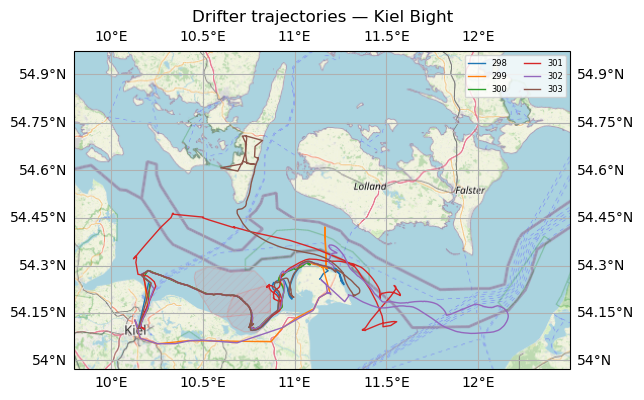

In [3]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

tiles = cimgt.OSM()
fig, ax = plt.subplots(subplot_kw={"projection": tiles.crs})

ax.set_extent([9.8, 12.5, 54.2, 55.2], crs=ccrs.Geodetic())
ax.add_image(tiles, 8)
ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree())

for d_num, grp in df.groupby(level="D_number"):
    ax.plot(grp["Longitude"].values, grp["Latitude"].values,
            linewidth=1, transform=ccrs.Geodetic(), label=d_num)

ax.legend(fontsize=6, ncol=2)
ax.set_title("Drifter trajectories — Kiel Bight")
plt.show()